In [1]:
import numpy as np
import pandas as pd
import io 
import os

import ftplib
from ftplib import FTP

## Conectando ao Servidor FTP

In [2]:
ftp_server = "ftp.dadosabertos.ans.gov.br"

In [35]:
class SmartFTP(FTP):
    def makepasv(self):
        invalidhost, port = super(SmartFTP, self).makepasv()
        return self.host, port


In [36]:
ftp = SmartFTP(ftp_server)

### Login

In [37]:
ftp.login()

'230 Login successful.'

In [38]:
ftp.encoding = 'Utf-8'

In [39]:
print(ftp.getwelcome())

220 'Arquivos de Dados Publicos ANS'


### Verificando os diretórios existentes

In [40]:
print(ftp.dir())

drwxrwxr-x    4 0        0              38 Aug 25  2023 FTP
drwxr-sr-x    2 0        0              17 Jan 25 12:45 dev
None


### Navegação dentro do servidor FTP

In [41]:
# Inserir o nome do diretório a ser acessado
ftp.cwd('FTP')
ftp.dir()

drwxrwxr-x    3 1001     1001           24 Aug 21  2023 Base_de_dados
drwxrwxr-x   53 1001     1001         4096 Jan 17 14:00 PDA


In [42]:
#Nivel 3 da arvore do FTP
ftp.cwd('PDA')

print("Arquivos disponiveis")
print("***********************")
print()
print('\n'.join(ftp.nlst()))
print()
print("***********************")

Arquivos disponiveis
***********************

Caderno_SS
IAP
IGR
PFA
RPC
SIP
TISS
agenda_de_autoridades
area_comercializacao_planos_ntrp
beneficiarios_identificados_sus_abi
beneficiarios_vinculos_tipo_contratacao_vda
caderno_de_informacao
caracteristicas_produtos_saude_suplementar-008
dados_consolidados_da_saude_suplementar
dados_de_beneficiarios_por_operadora
dados_de_beneficiarios_por_regiao_geografica
dados_ressarcimento_SUS_operadora_planos_saude
dataset_teste
demandas_dos_consumidores_nip
demandas_dos_consumidores_reclamacao_beneficiarios
demonstracoes_contabeis
faixa_de_preco
glossario_saude_suplementar
hc_ressarcimento_sus
historico_idss-020
historico_planos_saude
informacoes_consolidadas_de_beneficiarios-024
monitoramento_garantia_atendimento
nota_tecnica_ntrp_vcm_faixa_etaria
operadoras_acreditadas
operadoras_de_plano_de_saude_ativas
operadoras_de_plano_de_saude_canceladas
operadoras_e_prestadores_nao_hospitalares
painel_de_precificacao
penalidades_aplicadas_a_operadoras
peona

## Arquivo: Operadoras ativas

In [43]:
ftp.cwd('operadoras_de_plano_de_saude_ativas')

'250 Directory successfully changed.'

In [44]:
ftp.nlst()

['Relatorio_cadop.csv', 'dicionario_de_dados_das_operadoras_ativas.ods']

In [45]:
!pip install odfpy

In [50]:
ftpfile = open('ftpfile', 'wb')
file_csv = 'Relatorio_cadop.csv'

file_dicio = 'dicionario_de_dados_das_operadoras_ativas.ods'



In [ ]:
df = pd.read_excel('seuarquivo.ods', engine='odf', sheet_name=0)

In [15]:
def lerfile_ftp(file):
    download_file = io.BytesIO()

    ftp.retrbinary('RETR ' + str(file), download_file.write)

    download_file.seek(0)
    return download_file

### Lendo arquivo para dataframe

In [46]:

ope_ativas = pd.read_fwf(lerfile_ftp(file_csv), encoding = 'utf-8', sep = ';')

linhas = [v for v in [ope_ativas.values]][0]
oper_ativas_list = [l.split(';') for l in linhas[:, 0] ]
colunas = [c.split(';') for c in ope_ativas.columns.tolist()]

In [47]:
oper_ativas = pd.DataFrame(data = oper_ativas_list, columns = colunas[0])

In [48]:
for c in oper_ativas.columns:
    
    oper_ativas[c] = oper_ativas[c].str.replace('"', "").replace("  ", " ")
    oper_ativas[c] = oper_ativas[c].squeeze()
    

In [81]:
dicio = pd.read_excel(lerfile_ftp(file_dicio), engine='odf')

colunas = dicio.dropna().reset_index(drop = True).values.tolist()[0]

dicio.columns = colunas
dicio.dropna(inplace = True)
dicio.reset_index(drop = True, inplace = True)
dicio = dicio.loc[1:, :]

In [82]:
dicio

,Nome do Campo,Tipo,Tamanho,Descrição
1,REGISTRO_OPERADORA,Texto,6,Registro de operadora de plano privado de assi...
2,CNPJ,Texto,14,CNPJ da Operadora
3,Razao_Social,Texto,140,Razão Social da Operadora
4,Nome_Fantasia,Texto,140,Nome Fantasia da Operadora
5,Modalidade,Texto,2,Classificação das operadoras deplanos privados...
6,Logradouro,Texto,40,Endereço da Sede da Operadora
7,Número,Texto,20,Número do Endereço da Sede da Operadora
8,Complemento,Texto,40,Complemento do Endereço da Sede da Operadora
9,Bairro,Texto,30,Bairro do Endereço da Sede da Operadora
10,Cidade,Texto,30,Cidade do Endereço da Sede da Operadora


#### Análise

In [19]:
oper_ativas.head()

,Registro_ANS,CNPJ,Razao_Social,Nome_Fantasia,Modalidade,Logradouro,Numero,Complemento,Bairro,Cidade,UF,CEP,DDD,Telefone,Fax,Endereco_eletronico,Representante,Cargo_Representante,Regiao_de_Comercializacao,Data_Registro_ANS
0,419761,19541931000125,18 DE JULHO ADMINISTRADORA DE BENEFÍCIOS LTDA,,Administradora de Benefícios,RUA CAPITÃO MEDEIROS DE REZENDE,274,,PRAÇA DA BANDEIRA,Além Paraíba,MG,36660000,32,34624649,,contabilidade@cbnassessoria.com.br,LUIZ HENRIQUE MARENDINO GONÇALVES,SÓCIO ADMINISTRADOR,6,2015-05-19
1,421545,22869997000153,2B ODONTOLOGIA OPERADORA DE PLANOS ODONTOLÓGIC...,,Odontologia de Grupo,RUA CATÃO,128,SALA 126,VILA ROMANA,São Paulo,SP,05049000,11,34415852,,labmarisol@gmail.com,MARISOL BECHELLI,SÓCIO ADMINISTRADORA,4,2019-06-13
2,421421,27452545000195,2CARE OPERADORA DE SAÚDE LTDA.,,Medicina de Grupo,RUA: BERNARDINO DE CAMPOS,230,1º ANDAR,CENTRO,Campinas,SP,13010151,19,37901224,,ans.plano@hospitalcare.com.br,RODRIGO PINHO RIBEIRO,REPRESENTANTE,5,2018-10-09
3,422908,41788751000100,3S ADMINISTRADORA DE BENEFICIOS LTDA,3S ADMINISTRADORA DE BENEFICIOS,Administradora de Benefícios,RUA ITÁLIA,33,SALA 6,JARDIM BONFIGLIOLI,Jundiaí,SP,13207280,11,42263247,,pietrorocchi37@gmail.com,ANAMELIA MONTEIRO GUERRA ROCCHI,SÓCIO ADMINISTRADOR,6,2021-07-12
4,418030,13138885000131,A.P.S. ADMINISTRADORA DE BENEFÍCOS LTDA.,A.P.S. SAÚDE.,Administradora de Benefícios,RUA VOLUNTÁRIOS DA PÁTRIA,2525,CONJUNTO 143 - SALA 01,SANTANA,São Paulo,SP,02401000,11,45223468,,diretoria@apssaude.com.br,PERCÍVEL GAETA,SóCIO-ADMINISTRADOR E REPRESEN,4,2011-05-05


In [19]:
oper_ativas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1122 entries, 0 to 1121
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Registro_ANS               1122 non-null   object
 1   CNPJ                       1122 non-null   object
 2   Razao_Social               1122 non-null   object
 3   Nome_Fantasia              1122 non-null   object
 4   Modalidade                 1122 non-null   object
 5   Logradouro                 1122 non-null   object
 6   Numero                     1122 non-null   object
 7   Complemento                1122 non-null   object
 8   Bairro                     1122 non-null   object
 9   Cidade                     1122 non-null   object
 10  UF                         1122 non-null   object
 11  CEP                        1122 non-null   object
 12  DDD                        1122 non-null   object
 13  Telefone                   1122 non-null   object
 14  Fax     

In [27]:
oper_ativas['Registro_ANS'].value_counts().head(10)

#Não há operadoras duplicadas

Registro_ANS
419761    1
343889    1
343765    1
344141    1
350346    1
323357    1
334561    1
303976    1
304468    1
345598    1
Name: count, dtype: int64

In [22]:
import matplotlib.pyplot as plt

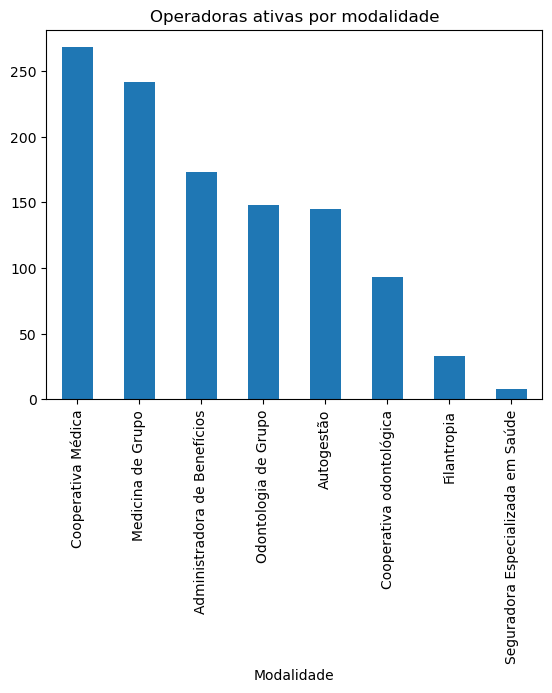

In [29]:
oper_ativas["Modalidade"].value_counts().plot.bar(title = 'Operadoras ativas por modalidade')

plt.show()

In [23]:
oper_ativas["UF"].value_counts()

UF
SP    384
MG    137
RJ    135
PR     71
RS     61
BA     43
SC     35
DF     35
ES     33
GO     24
PE     18
CE     17
PB     15
MT     14
AL     14
RN     13
PA     13
MS     11
SE     10
RO     10
AM      8
PI      8
TO      4
MA      4
AP      2
AC      2
RR      1
Name: count, dtype: int64

In [24]:
oper_ativas["Representante"].value_counts().head(10)

Representante
LUIZ CELSO DIAS LOPES                8
RAQUEL REIS CORREA                   5
JOÃO DE FIGUEIREDO PEREIRA CURADO    5
FÁBIO MINAMISAWA HIROTA              4
ALEXANDRE GINO CAMARGO ZORNIG        4
ANTONIO CARLOS ANTUNES BASTOS        3
LUIZ VICENTE GUARANHA LAPENTA        3
PATRICIA MELO E SOUZA                2
MARCELO COUTO LUNA DE ALMEIDA        2
BRUNO CAMARA MEIRA                   2
Name: count, dtype: int64

In [25]:
oper_ativas[oper_ativas["Representante"].str.contains('LUIZ CELSO DIAS LOPES')]

,Registro_ANS,CNPJ,Razao_Social,Nome_Fantasia,Modalidade,Logradouro,Numero,Complemento,Bairro,Cidade,UF,CEP,DDD,Telefone,Fax,Endereco_eletronico,Representante,Cargo_Representante,Regiao_de_Comercializacao,Data_Registro_ANS
156,402966,03123146000112,BIO SAÚDE SERVIÇOS MÉDICOS LTDA,BIO SAÚDE,Medicina de Grupo,AVENIDA PAULISTA,777,2º ANDAR,BELA VISTA,São Paulo,SP,01311914,11,34693100,32421800,ans@hapvida.com.br,LUIZ CELSO DIAS LOPES,REPRESENTANTE LEGAL DA OPERADORA,4,1999-03-31
220,392804,00773639000100,CENTRO CLÍNICO GAÚCHO LTDA,CENTRO CLÍNICO GAÚCHO,Medicina de Grupo,RUA DONA MARGARIDA,537,,NAVEGANTES,Porto Alegre,RS,90240611,14,32879212,32879231,ans@hapvida.com.br,LUIZ CELSO DIAS LOPES,REPRESENTANTE LEGAL DA OPERADORA,4,1998-12-29
233,340782,76882612000117,CLINIPAM CLINICA PARANAENSE DE ASSISTENCIA MED...,GNDI SUL,Medicina de Grupo,RUA XV DE NOVEMBRO,575,4º E 5º ANDARES,CENTRO,Curitiba,PR,80020310,41,30213000,30213060,ans@hapvida.com.br,LUIZ CELSO DIAS LOPES,DIRETOR EXECUTIVO,4,1998-12-22
362,350249,02668512000156,H.B. SAÚDE S/A.,HB SAÚDE,Medicina de Grupo,AV. JOSÉ MUNIA,6250,,JARDIM FRANCISCO FERNANDES,São José do Rio Preto,SP,15090275,,,,cians@hapvida.com.br,LUIZ CELSO DIAS LOPES,REPRESENTANTE LEGAL DA OPERADORA,5,1998-12-16
365,368253,63554067000198,HAPVIDA ASSISTENCIA MEDICA S.A.,HAPVIDA,Medicina de Grupo,AV HERÁCLITO GRAÇA,406,2º ANDAR,CENTRO,Fortaleza,CE,60140060,85,32559189,,cians@hapvida.com.br,LUIZ CELSO DIAS LOPES,REPRESENTANTE DA PESSOA JURÍDICA JUNTO A,5,1998-12-17
484,348520,62550256000120,NOTRE DAME INTERMÉDICA MINAS GERAIS SAÚDE S.A.,GNDI MINAS,Medicina de Grupo,AVENIDA PAULISTA,867,"6º ANDAR, CONJUNTO 61, SALA 2",BELA VISTA,São Paulo,SP,01311100,31,31662369,40032852,ans@hapvida.com.br,LUIZ CELSO DIAS LOPES,REPRESENTANTE LEGAL DA OPERADORA,4,1999-01-06
485,359017,44649812000138,NOTRE DAME INTERMÉDICA SAÚDE S.A.,,Medicina de Grupo,AVENIDA PAULISTA,867,,BELA VISTA,São Paulo,SP,01311100,11,31555360,,ans@hapvida.com.br,LUIZ CELSO DIAS LOPES,DIRETOR SEM DESIGNAÇÃO ESPECIFICA,4,1998-12-16
712,344362,96509690000188,SÃO LUCAS SAÚDE S/A,SÃO LUCAS SAÚDE,Medicina de Grupo,AV. BRASIL,1530,,SANTO ANTONIO,Americana,SP,13465770,19,34771000,34771004,ans@intermedica.com.br,LUIZ CELSO DIAS LOPES,REPRESENTANTE LEGAL,5,1998-12-23


In [26]:
oper_ativas["Cargo_Representante"].value_counts().head(20)

Cargo_Representante
PRESIDENTE                200
DIRETOR PRESIDENTE        194
REPRESENTANTE              77
ADMINISTRADOR              64
REPRESENTANTE LEGAL        45
SÓCIO ADMINISTRADOR        39
DIRETOR                    26
SOCIO ADMINISTRADOR        21
DIRETORA PRESIDENTE        17
SÓCIA ADMINISTRADORA       15
Administrador              14
SÓCIO-ADMINISTRADOR        13
PROVEDOR                   10
Diretor Presidente         10
DIRETOR ADMINISTRATIVO     10
ADMINISTRADORA              8
SUPERINTENDENTE             8
Sócio Administrador         8
DIRETOR GERAL               7
DIRETOR EXECUTIVO           7
Name: count, dtype: int64

In [27]:
oper_ativas[oper_ativas["Razao_Social"].str.contains('CAIXA DE ASSIS')]

,Registro_ANS,CNPJ,Razao_Social,Nome_Fantasia,Modalidade,Logradouro,Numero,Complemento,Bairro,Cidade,UF,CEP,DDD,Telefone,Fax,Endereco_eletronico,Representante,Cargo_Representante,Regiao_de_Comercializacao,Data_Registro_ANS
0,418374,11828089000103,CAIXA DE ASSISTÊNCIA DO SETOR DE ENERGIA -EVI...,E-VIDA,Autogestão,SETOR DE HABITAÇÕES COLETIVAS GEMINADAS,QUADRA 704/705,"BLOCO C, LOJA 48",ASA NORTE,Brasília,DF,70730630,61,39668300,,negocios@evida.org.br,JORGE EDUARDO BRAGA NETO,PRESIDENTE,4,2012-01-12
177,316873,73395469000140,CAIXA DE ASSISTENCIA A SAUDE DA UNIVERSIDADE,CASU/UFMG,Autogestão,AV. ANTÔNIO CARLOS,6627,LOJA 1 PRAÇA DE SERVIÇOS,PAMPULHA,Belo Horizonte,MG,31270901,31,34997200,34997200,casu@casu.com.br,MARCOS ROBERTO MOREIRA RIBEIRO,Diretor Presidente,4,1998-12-22
178,413534,04311093000126,CAIXA DE ASSISTENCIA DOS SERVIDORES DO ESTADO ...,CASSEMS,Autogestão,RUA ANTONIO MARIA COELHO,6065,,VIVENDAS DO BOSQUE,Campo Grande,MS,79021170,67,33091046,,juridico@cassems.com.br,RICARDO AYACHE,PRESIDENTE CONS. ADMINISTRAÇÃO,3,2001-04-16
179,418820,27085968000114,CAIXA DE ASSISTÊNCIA AOS MEMBROS DA DEFENSORIA...,CAMARJ,Autogestão,RUA DO CARMO,7,2º ANDAR,CENTRO,Rio de Janeiro,RJ,20011020,21,25335995,,CAMARJ@CAMARJ.COM.BR,PAULO VINICIUS COZZOLINO ABRAHÃO,DIRETOR PRESIDENTE,3,2013-03-25
180,413518,04197511000104,CAIXA DE ASSISTÊNCIA DO SINDFISCO - CASSIND,CASSIND,Autogestão,RUA JORNALISTA JOÃO BATISTA DE SANTANA,1914,,COROA DO MEIO,Aracaju,SE,49035430,79,32551696,32553525,cassind@cassind.com.br,BALBINO JOSÉ SILVA NETO,REPRESENTANTE,3,2001-04-09
181,416401,08097092000181,CAIXA DE ASSISTÊNCIA DOS EMPREGADOS DA EMPRESA...,CASEMBRAPA,Autogestão,PARQUE EST. BIOL. - W3 NORTE FINAL,S/N,BLOCO A,ASA NORTE,Brasília,DF,70770901,61,31810010,31810010,presidencia@casembrapa.org.br,ALAN AUGUSTO DOS REIS,PRESIDENTE,4,2007-10-30
182,363855,37382009000114,CAIXA DE ASSISTÊNCIA DOS EMPREGADOS DA SANEAGO,CAESAN,Autogestão,AVENIDA C,576,QUADRA A-26 - LOTE 11,JARDIM GOIÁS,Goiânia,GO,74805070,62,32677300,,caesan@caesan.com.br,JOSÉ ROGÉRIO DA SILVA,DIRETOR PRESIDENTE,3,1998-12-22
183,307319,02315431000172,CAIXA DE ASSISTÊNCIA DOS EMPREGADOS DO BANCO D...,CABERGS,Autogestão,RUA SIQUEIRA CAMPOS,736,11 º AND,CENTRO,Porto Alegre,RS,90010000,51,32629167,32629167,paulonunes@cabergs.org.br,PAULO ROBERTO NUNES DOS SANTOS,GERENTE DE ASSISTÊNCIA À SAÚDE,3,1998-12-18
184,315583,15215452000168,CAIXA DE ASSISTÊNCIA DOS EMPREGADOS DO BANEB,CASSEB,Autogestão,RUA METODIO COELHO,133,CIDADELA,PARQUE BELA VISTA,Salvador,BA,40279120,71,34440500,33588852,casseb@casseb.com.br,ERENALDO DE SOUSA BRITO,PRESIDENTE,3,1998-12-30
185,335789,13086566000120,CAIXA DE ASSISTÊNCIA DOS EMPREGADOS DO BANESE,CASSE,Autogestão,RUA OLÍMPIO DE SOUZA CAMPOS JÚNIOR,98A,DISTRITO INDUSTRIAL DE ARACAJU-DIA,INÁCIO BARBOSA,Aracaju,SE,49042840,79,32184339,,casses@banese.com.br,CAROLINA DA SILVA BEZERRA BEIRAL,PRESIDENTE,3,1998-12-22


In [28]:
oper_ativas[oper_ativas["Nome_Fantasia"].str.contains('CASSI')]

,Registro_ANS,CNPJ,Razao_Social,Nome_Fantasia,Modalidade,Logradouro,Numero,Complemento,Bairro,Cidade,UF,CEP,DDD,Telefone,Fax,Endereco_eletronico,Representante,Cargo_Representante,Regiao_de_Comercializacao,Data_Registro_ANS
180,413518,04197511000104,CAIXA DE ASSISTÊNCIA DO SINDFISCO - CASSIND,CASSIND,Autogestão,RUA JORNALISTA JOÃO BATISTA DE SANTANA,1914,,COROA DO MEIO,Aracaju,SE,49035430,79,32551696,32553525,cassind@cassind.com.br,BALBINO JOSÉ SILVA NETO,REPRESENTANTE,3,2001-04-09
189,346659,33719485000127,CAIXA DE ASSISTÊNCIA DOS FUNCIONÁRIOS DO BANCO...,CASSI,Autogestão,"SIG, Quadra 4, Lote",575,---,ASA SUL,Brasília,DF,70610910,61,32125000,33106944,planos@cassi.com.br,WILLIAM HUANG,REPRESENTANTE JUNTO À ANS,1,1998-12-29


In [29]:
oper_ativas["Regiao_de_Comercializacao"].value_counts()

Regiao_de_Comercializacao
5    485
4    187
6    183
     114
3     72
1     53
2     19
Name: count, dtype: int64

In [30]:
ftp.cwd('..')

'250 Directory successfully changed.'

In [31]:
ftp.nlst()

['Caderno_SS',
 'IAP',
 'IGR',
 'PFA',
 'RPC',
 'SIP',
 'TISS',
 'agenda_de_autoridades',
 'area_atuacao_planos_saude',
 'area_comercializacao_planos_ntrp',
 'beneficiarios_identificados_sus_abi',
 'beneficiarios_vinculos_tipo_contratacao_vda',
 'caderno_de_informacao',
 'caracteristicas_produtos_saude_suplementar',
 'caracteristicas_produtos_saude_suplementar-008',
 'dados_consolidados_da_saude_suplementar',
 'dados_de_beneficiarios_por_operadora',
 'dados_de_beneficiarios_por_regiao_geografica',
 'dados_ressarcimento_SUS_operadora_planos_saude',
 'dataset_teste',
 'demandas_dos_consumidores_nip',
 'demandas_dos_consumidores_reclamacao_beneficiarios',
 'demonstracoes_contabeis',
 'detalhamento_area_geografica-016',
 'faixa_de_preco',
 'glossario_saude_suplementar',
 'hc_ressarcimento_sus',
 'historico_idss',
 'historico_idss-020',
 'historico_planos_saude',
 'informacoes_consolidadas_de_beneficiarios-024',
 'monitoramento_garantia_atendimento',
 'nota_tecnica_ntrp_vcm_faixa_etaria',
 

In [32]:
ftp.cwd('dados_de_beneficiarios_por_operadora')

'250 Directory successfully changed.'

In [33]:
ftp.nlst()

['dicionario_de_dados_sib.ods', 'sib_ativos.zip', 'sib_inativos.zip']

In [44]:
caminho = r"E:\portfolio\estudo\bases\sib_ativos"

In [41]:
os.listdir(caminho)

['sib_202112_AC.csv',
 'sib_202112_AL.csv',
 'sib_202112_AM.csv',
 'sib_202112_AP.csv',
 'sib_202112_BA.csv',
 'sib_202112_CE.csv',
 'sib_202112_DF.csv',
 'sib_202112_ES.csv',
 'sib_202112_GO.csv',
 'sib_202112_MA.csv',
 'sib_202112_MG.csv',
 'sib_202112_MS.csv',
 'sib_202112_MT.csv',
 'sib_202112_PA.csv',
 'sib_202112_PB.csv',
 'sib_202112_PE.csv',
 'sib_202112_PI.csv',
 'sib_202112_PR.csv',
 'sib_202112_RJ.csv',
 'sib_202112_RN.csv',
 'sib_202112_RO.csv',
 'sib_202112_RR.csv',
 'sib_202112_RS.csv',
 'sib_202112_SC.csv',
 'sib_202112_SE.csv',
 'sib_202112_SP.csv',
 'sib_202112_TO.csv',
 'sib_202405_AC.csv',
 'sib_202405_AL.csv',
 'sib_202405_AM.csv',
 'sib_202405_AP.csv',
 'sib_202405_BA.csv',
 'sib_202405_CE.csv',
 'sib_202405_DF.csv',
 'sib_202405_ES.csv',
 'sib_202405_GO.csv',
 'sib_202405_MA.csv',
 'sib_202405_MG.csv',
 'sib_202405_MS.csv',
 'sib_202405_MT.csv',
 'sib_202405_PA.csv',
 'sib_202405_PB.csv',
 'sib_202405_PE.csv',
 'sib_202405_PI.csv',
 'sib_202405_PR.csv',
 'sib_2024

In [52]:
benef_ativos = pd.read_csv(caminho+'\sib_202405_AC.csv', encoding='latin1', sep = ';', on_bad_lines='skip')

C:\Users\jeffe\AppData\Local\Temp\ipykernel_21724\2022790673.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  benef_ativos = pd.read_csv(caminho+'\sib_202405_AC.csv', encoding='latin1', sep = ';', on_bad_lines='skip')


In [46]:
pd.options.display.max_columns = 999


In [53]:
benef_ativos.columns

Index(['ID_TEMPO_COMPETENCIA', 'CD_OPERADORA', 'DT_INCLUSAO',
       'CD_BENE_MOTV_INCLUSAO', 'IND_PORTABILIDADE', 'ID_MOTIVO_MOVIMENTO',
       'LG_BENEFICIARIO_ATIVO', 'DT_NASCIMENTO', 'TP_SEXO', 'CD_PLANO_RPS',
       'CD_PLANO_SCPA', 'NR_PLANO_PORTABILIDADE', 'DT_PRIMEIRA_CONTRATACAO',
       'DT_CONTRATACAO', 'ID_BENE_TIPO_DEPENDENTE', 'LG_COBERTURA_PARCIAL',
       'LG_ITEM_EXCLUIDO_COBERTURA', 'CD_MUNICIPIO', 'SG_UF',
       'LG_RESIDE_EXTERIOR', 'DT_REATIVACAO', 'DT_ULTIMA_REATIVACAO',
       'DT_ULTIMA_MUDA_CONTRATUAL', 'DT_CANCELAMENTO',
       'DT_ULTIMO_CANCELAMENTO', 'CD_BENE_MOTIV_CANCELAMENTO', 'DT_CARGA'],
      dtype='object')

In [54]:
benef_ativos.head()

,ID_TEMPO_COMPETENCIA,CD_OPERADORA,DT_INCLUSAO,CD_BENE_MOTV_INCLUSAO,IND_PORTABILIDADE,ID_MOTIVO_MOVIMENTO,LG_BENEFICIARIO_ATIVO,DT_NASCIMENTO,TP_SEXO,CD_PLANO_RPS,CD_PLANO_SCPA,NR_PLANO_PORTABILIDADE,DT_PRIMEIRA_CONTRATACAO,DT_CONTRATACAO,ID_BENE_TIPO_DEPENDENTE,LG_COBERTURA_PARCIAL,LG_ITEM_EXCLUIDO_COBERTURA,CD_MUNICIPIO,SG_UF,LG_RESIDE_EXTERIOR,DT_REATIVACAO,DT_ULTIMA_REATIVACAO,DT_ULTIMA_MUDA_CONTRATUAL,DT_CANCELAMENTO,DT_ULTIMO_CANCELAMENTO,CD_BENE_MOTIV_CANCELAMENTO,DT_CARGA
0,202405,403997,2010-08,11.0,NAO,74.0,1,1985,M,428204993.0,NaN,NaN,2010-07,2010-07,3.0,0.0,0.0,120040,AC,0,NaN,NaN,NaN,NaN,NaN,NaN,2024-07
1,202405,403997,2009-04,11.0,NAO,74.0,1,1996,F,428204993.0,NaN,NaN,2009-03,2009-03,10.0,0.0,0.0,120040,AC,0,NaN,NaN,NaN,NaN,NaN,NaN,2024-07
2,202405,403997,2010-07,11.0,NAO,74.0,1,1990,F,428204993.0,NaN,NaN,2000-05,2000-05,4.0,0.0,0.0,120040,AC,0,NaN,NaN,NaN,NaN,NaN,NaN,2024-07
3,202405,403997,2010-04,11.0,NAO,74.0,1,1995,M,428204993.0,NaN,NaN,2010-03,2010-03,4.0,0.0,0.0,120040,AC,0,NaN,NaN,NaN,NaN,NaN,NaN,2024-07
4,202405,403997,2006-05,11.0,NAO,74.0,1,1994,M,428204993.0,NaN,NaN,2006-04,2006-04,4.0,0.0,0.0,120040,AC,0,NaN,NaN,NaN,NaN,NaN,NaN,2024-07


In [55]:
benef_ativos.shape

(65682, 27)

In [56]:
benef_ativos.describe(include='all')

,ID_TEMPO_COMPETENCIA,CD_OPERADORA,DT_INCLUSAO,CD_BENE_MOTV_INCLUSAO,IND_PORTABILIDADE,ID_MOTIVO_MOVIMENTO,LG_BENEFICIARIO_ATIVO,DT_NASCIMENTO,TP_SEXO,CD_PLANO_RPS,CD_PLANO_SCPA,NR_PLANO_PORTABILIDADE,DT_PRIMEIRA_CONTRATACAO,DT_CONTRATACAO,ID_BENE_TIPO_DEPENDENTE,LG_COBERTURA_PARCIAL,LG_ITEM_EXCLUIDO_COBERTURA,CD_MUNICIPIO,SG_UF,LG_RESIDE_EXTERIOR,DT_REATIVACAO,DT_ULTIMA_REATIVACAO,DT_ULTIMA_MUDA_CONTRATUAL,DT_CANCELAMENTO,DT_ULTIMO_CANCELAMENTO,CD_BENE_MOTIV_CANCELAMENTO,DT_CARGA
count,65682.0,65682.000000,65682,60538.000000,65682,65042.000000,65682.0,65682.000000,65682,6.093400e+04,4704,1.290000e+02,65682,65682,65642.000000,55174.000000,55043.000000,65682.000000,65682,65682.0,3607,3607,6041,3607,3607,3607.000000,65682
unique,NaN,NaN,279,NaN,2,NaN,NaN,NaN,2,NaN,118,NaN,512,424,NaN,NaN,NaN,NaN,1,NaN,191,188,181,212,200,NaN,1
top,NaN,NaN,2006-01,NaN,NAO,NaN,NaN,NaN,F,NaN,001,NaN,2023-11,2024-04,NaN,NaN,NaN,NaN,AC,NaN,2019-12,2022-03,2021-03,2019-07,2019-08,NaN,2024-07
freq,NaN,NaN,4168,NaN,65553,NaN,NaN,NaN,35535,NaN,972,NaN,1650,1792,NaN,NaN,NaN,NaN,65682,NaN,194,201,668,197,195,NaN,65682
mean,202405.0,320965.228373,NaN,11.727328,NaN,60.295179,1.0,1986.615405,NaN,4.559904e+08,NaN,4.605772e+08,NaN,NaN,2.296396,0.056168,0.032502,120038.684556,NaN,0.0,NaN,NaN,NaN,NaN,NaN,42.278625,NaN
std,0.0,94744.062481,NaN,6.536339,NaN,23.051584,0.0,20.843695,NaN,4.215087e+07,NaN,2.919486e+07,NaN,NaN,2.065248,0.230247,0.177330,7.919518,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.718773,NaN
min,202405.0,582.000000,NaN,11.000000,NaN,11.000000,1.0,1944.000000,NaN,4.000460e+08,NaN,4.018410e+08,NaN,NaN,1.000000,0.000000,0.000000,120000.000000,NaN,0.0,NaN,NaN,NaN,NaN,NaN,41.000000,NaN
25%,202405.0,323080.000000,NaN,11.000000,NaN,51.000000,1.0,1972.000000,NaN,4.282050e+08,NaN,4.574211e+08,NaN,NaN,1.000000,0.000000,0.000000,120040.000000,NaN,0.0,NaN,NaN,NaN,NaN,NaN,42.000000,NaN
50%,202405.0,337871.000000,NaN,11.000000,NaN,74.000000,1.0,1987.000000,NaN,4.581581e+08,NaN,4.628041e+08,NaN,NaN,1.000000,0.000000,0.000000,120040.000000,NaN,0.0,NaN,NaN,NaN,NaN,NaN,42.000000,NaN
75%,202405.0,346659.000000,NaN,11.000000,NaN,74.000000,1.0,2003.000000,NaN,4.738812e+08,NaN,4.696531e+08,NaN,NaN,4.000000,0.000000,0.000000,120040.000000,NaN,0.0,NaN,NaN,NaN,NaN,NaN,43.000000,NaN


In [57]:
benef_ativos.groupby(["CD_OPERADORA", "DT_INCLUSAO"])[["LG_BENEFICIARIO_ATIVO"]].sum().sort_values("LG_BENEFICIARIO_ATIVO", ascending = False)

LG_BENEFICIARIO_ATIVO
CD_OPERADORA DT_INCLUSAO                       
337871       2006-01                       4162
374440       2023-12                        755
337871       2018-02                        683
339679       2020-04                        656
419419       2015-05                        602
...                                         ...
306886       2022-01                          1
             2023-11                          1
309907       2021-10                          1
             2023-09                          1
382337       2023-07                          1

[4189 rows x 1 columns]

In [58]:
benef_ativos.groupby(["CD_OPERADORA"])[["LG_BENEFICIARIO_ATIVO"]].sum().sort_values("LG_BENEFICIARIO_ATIVO", ascending = False)

,LG_BENEFICIARIO_ATIVO
CD_OPERADORA,
337871,24896
301949,6873
339679,4270
403997,4128
374440,3543
...,...
320862,1
415537,1
318477,1


In [ ]:
ftp.quit()